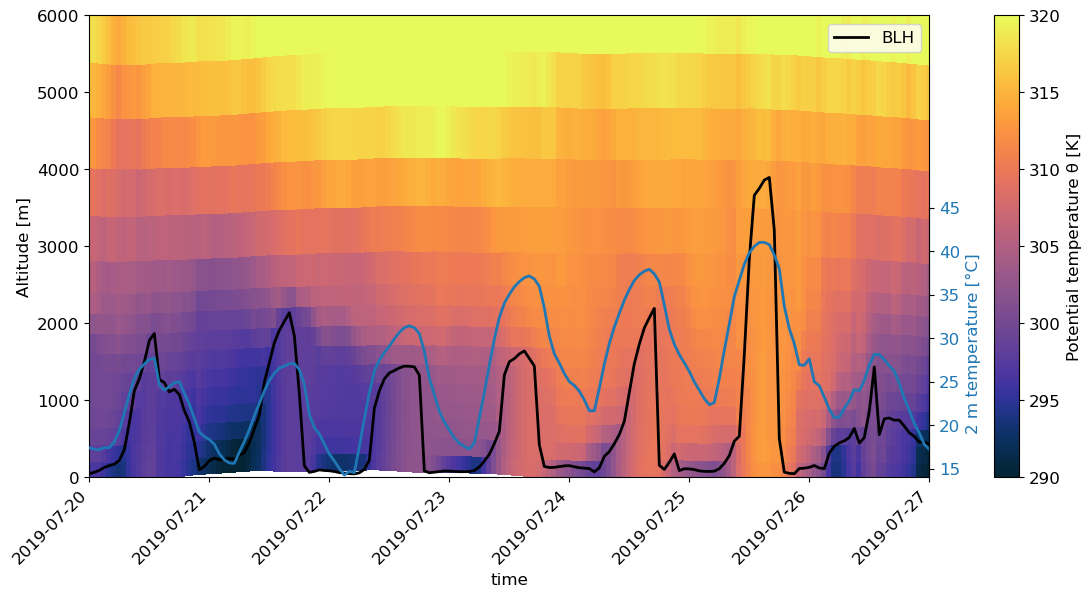

In [15]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean

plt.rcParams.update({'font.size': 12})

final_path = "/work/uc1275/u301827/02_MSE/paris/vertical_2019/"
start_date = "2019-07-20"
end_date   = "2019-07-27"

# constants
P0_HPA = 1000.0
R_D = 287.05
C_P = 1004.0
KAPPA = R_D / C_P
G = 9.81
top = 6000  # m

def open_era5(var):
    f = os.path.join(
        final_path, var,
        f"{var}_{pd.to_datetime(start_date):%Y%m%d}_{pd.to_datetime(end_date):%Y%m%d}_paris_hourly.nc"
    )
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")
    return xr.open_dataset(f)

# ---- read ----
t   = open_era5("t")["t"].squeeze(drop=True)      # (time, plev)
z   = open_era5("z")["z"].squeeze(drop=True)      # (time, plev)
blh = open_era5("blh")["blh"].squeeze(drop=True)  # (time)
t2m = open_era5("2t")["2t"].squeeze(drop=True)-273.15



# ensure datetime + align
t   = t.assign_coords(time=pd.to_datetime(t.time.values))
z   = z.assign_coords(time=pd.to_datetime(z.time.values))
blh = blh.assign_coords(time=pd.to_datetime(blh.time.values))
t2m = t2m.assign_coords(time=pd.to_datetime(t2m.time.values))
t, z, blh, t2m = xr.align(t, z, blh, t2m, join="inner")

plev = "plev"

# Pa -> hPa if needed
p = t[plev]
p_hpa = xr.where(p.max() > 2000, p / 100.0, p)

# potential temperature
theta = t * (P0_HPA / p_hpa) ** KAPPA
theta.name = "theta"

# height from geopotential (2D)
height = (z / G).rename("z")  # name it "z" for plotting

# sort by mean height (so vertical order is consistent)
theta  = theta.sortby(height.mean("time"))
height = height.sortby(height.mean("time"))

# attach height as a coordinate called "z"
theta = theta.assign_coords(z=height)

# ---- plot (like your plot b layout) ----
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(
    nrows=1, ncols=2,
    width_ratios=[20, 0.6],
    wspace=0.15
)

ax  = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

# --- main theta plot ---
pcm = theta.plot(
    ax=ax,
    x="time",
    y="z",
    cmap=cmocean.cm.thermal,
    vmin=290, vmax=320,
    add_colorbar=False,
)

cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label("Potential temperature θ [K]")

# BLH overlay
ax.plot(
    theta["time"].values,
    blh.values,
    color="black",
    linewidth=2,
    label="BLH"
)

ax.set_ylabel("Altitude [m]")
ax.set_ylim(0, top)
ax.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis="x", rotation=45)

ax.legend(loc="upper right")

# ----------------------------------------------------
# --- 2 m temperature axis (bottom 0–2500 m only) ---
# ----------------------------------------------------

# --- after you created ax and finished the theta plot, BLH, limits etc. ---

# fraction of ax height that corresponds to 0–3000 m
y0, y1 = ax.get_ylim()          # (0, top) in your case
zmax = 3500.0
frac = (zmax - y0) / (y1 - y0)  # e.g. 3000/6000 = 0.5

# create a new axes occupying only the bottom part of ax
pos = ax.get_position()
ax2 = fig.add_axes([pos.x0, pos.y0, pos.width, pos.height * frac], sharex=ax)

# make it look like a "right axis" overlay
ax2.patch.set_alpha(0)                 # transparent background
for spine in ["left", "top", "bottom"]:
    ax2.spines[spine].set_visible(False)
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")

# temperature axis limits
ax2.set_ylim(14, 45)  # your desired temp range

# plot 2t
ax2.plot(
    t2m["time"].values,
    t2m.values,
    color="tab:blue",
    linewidth=2
)

ax2.set_ylabel("2 m temperature [°C]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# don't duplicate x labels (keep them on the main ax)
ax2.tick_params(axis="x", which="both", bottom=False, labelbottom=False)


/work/uc1275/u301827/phd/lib/python3.7/site-packages/ipykernel_launcher.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


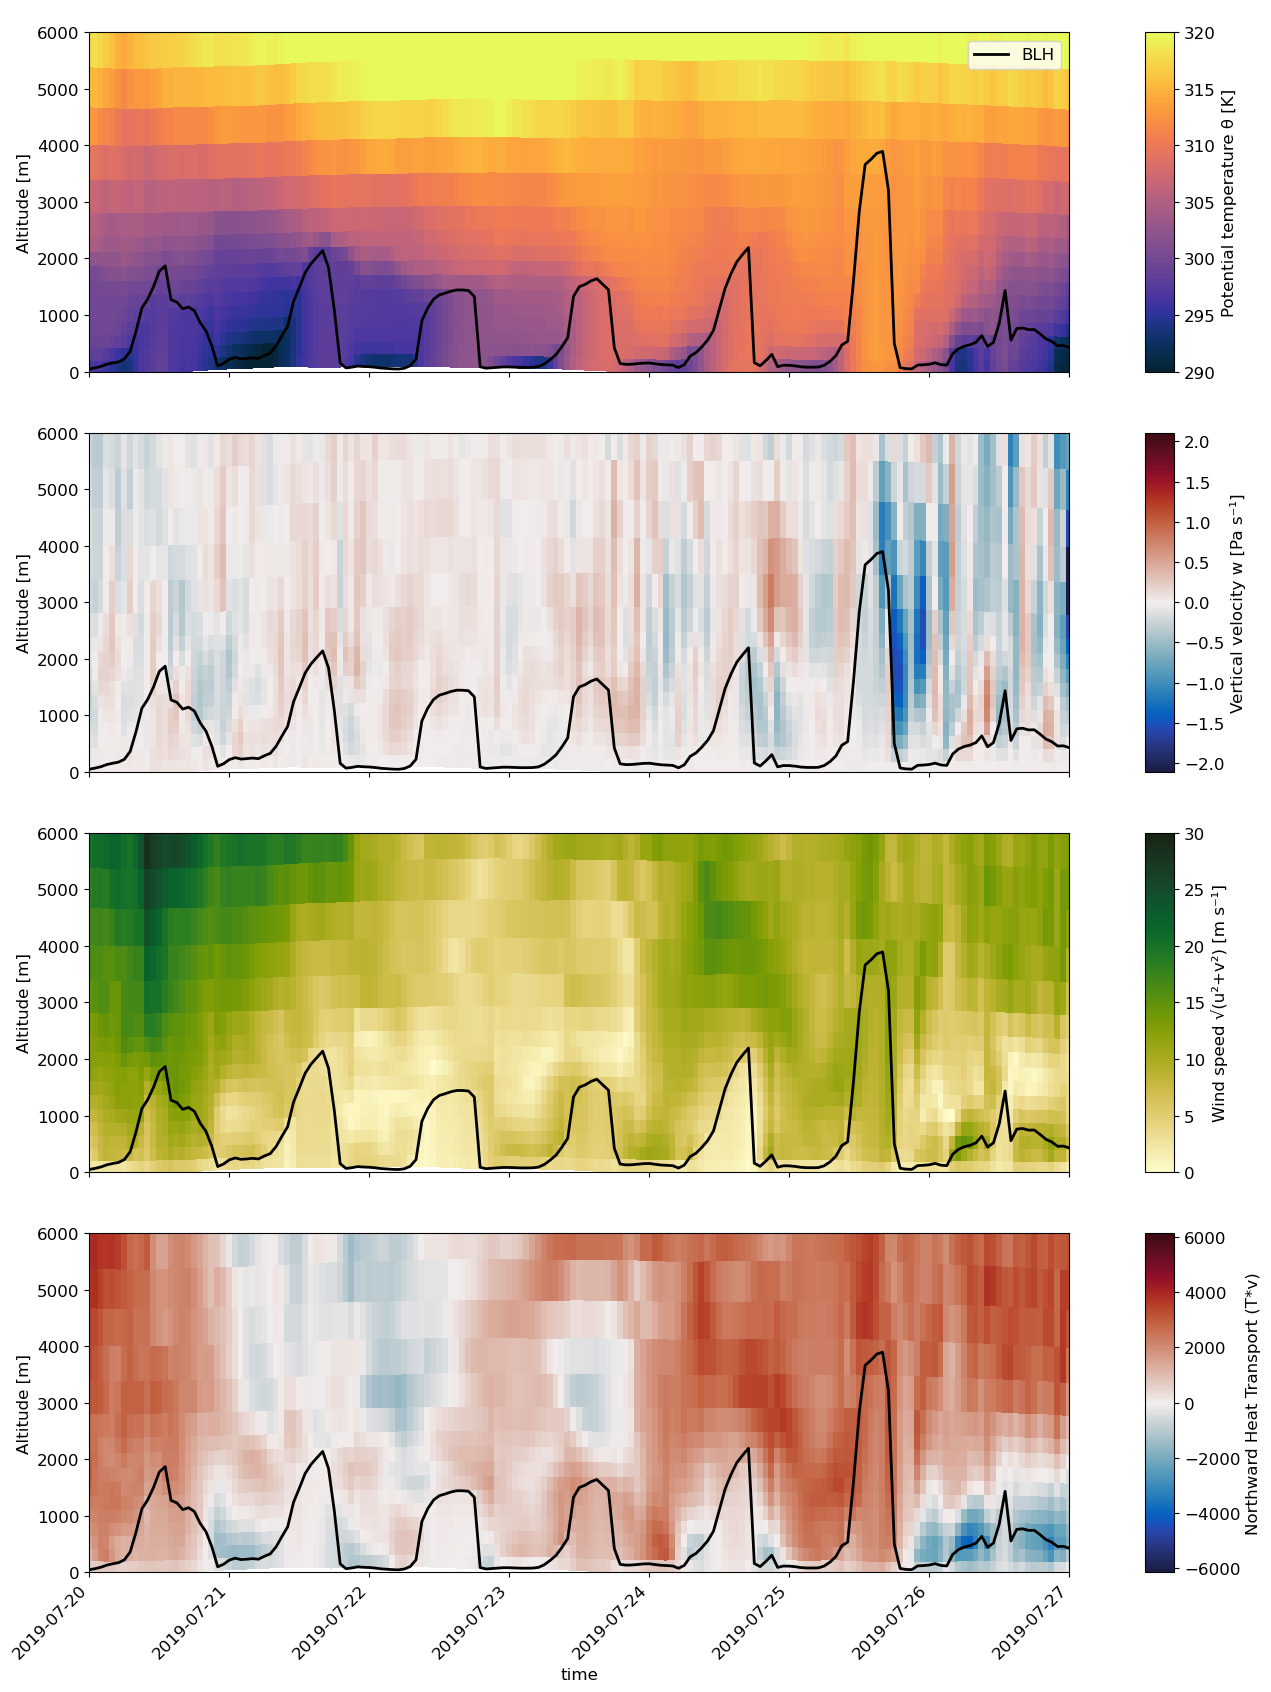

In [24]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean
import numpy as np

plt.rcParams.update({"font.size": 12})

final_path = "/work/uc1275/u301827/02_MSE/paris/vertical_2019/"
start_date = "2019-07-20"
end_date   = "2019-07-27"

# constants
P0_HPA = 1000.0
R_D = 287.05
C_P = 1004.0
KAPPA = R_D / C_P
G = 9.81
top = 6000  # m

def open_era5(var):
    f = os.path.join(
        final_path, var,
        f"{var}_{pd.to_datetime(start_date):%Y%m%d}_{pd.to_datetime(end_date):%Y%m%d}_paris_hourly.nc"
    )
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")
    return xr.open_dataset(f)

# ---- read ----
t   = open_era5("t")["t"].squeeze(drop=True)      # (time, plev)
z   = open_era5("z")["z"].squeeze(drop=True)      # (time, plev)
w   = open_era5("w")["w"].squeeze(drop=True)      # (time, plev) Pa/s
u   = open_era5("u")["u"].squeeze(drop=True)      # (time, plev) m/s
v   = open_era5("v")["v"].squeeze(drop=True)      # (time, plev) m/s
blh = open_era5("blh")["blh"].squeeze(drop=True)  # (time)

# ensure datetime + align
t   = t.assign_coords(time=pd.to_datetime(t.time.values))
z   = z.assign_coords(time=pd.to_datetime(z.time.values))
w   = w.assign_coords(time=pd.to_datetime(w.time.values))
u   = u.assign_coords(time=pd.to_datetime(u.time.values))
v   = v.assign_coords(time=pd.to_datetime(v.time.values))
blh = blh.assign_coords(time=pd.to_datetime(blh.time.values))
t, z, w, u, v, blh = xr.align(t, z, w, u, v, blh, join="inner")

plev = "plev"

# Pa -> hPa if needed
p = t[plev]
p_hpa = xr.where(p.max() > 2000, p / 100.0, p)

# potential temperature
theta = t * (P0_HPA / p_hpa) ** KAPPA
theta.name = "theta"

# height from geopotential (2D)
height = (z / G).rename("z")  # (time, plev), meters

# sort by mean height (so vertical order is consistent)
sort_key = height.mean("time")
theta  = theta.sortby(sort_key)
w      = w.sortby(sort_key)
u      = u.sortby(sort_key)
v      = v.sortby(sort_key)
height = height.sortby(sort_key)

# attach height as a coordinate called "z" for plotting
theta = theta.assign_coords(z=height)
w     = w.assign_coords(z=height)
u     = u.assign_coords(z=height)
v     = v.assign_coords(z=height)

# wind speed
wind = np.hypot(u, v)
wind.name = "wind"

# ---- plot: 3 rows, each with its own colorbar ----
# ---- plot: 4 rows, each with its own colorbar ----
fig = plt.figure(figsize=(14, 20))
gs = fig.add_gridspec(
    nrows=4, ncols=2,
    width_ratios=[20, 0.6],
    hspace=0.18,
    wspace=0.15
)

axes  = [fig.add_subplot(gs[i, 0]) for i in range(4)]
caxes = [fig.add_subplot(gs[i, 1]) for i in range(4)]

# 1) potential temperature θ
pcm1 = theta.plot(
    ax=axes[0], x="time", y="z",
    cmap=cmocean.cm.thermal,
    vmin=290, vmax=320,
    add_colorbar=False
)
cb1 = fig.colorbar(pcm1, cax=caxes[0])
cb1.set_label("Potential temperature θ [K]")

# 2) vertical velocity w (Pa/s)
pcm2 = w.plot(
    ax=axes[1], x="time", y="z",
    cmap=cmocean.cm.balance,
    add_colorbar=False
)
cb2 = fig.colorbar(pcm2, cax=caxes[1])
cb2.set_label("Vertical velocity w [Pa s⁻¹]")

# 3) horizontal wind speed √(u²+v²)
pcm3 = wind.plot(
    ax=axes[2], x="time", y="z",
    cmap=cmocean.cm.speed,
    vmin=0, vmax=30,
    add_colorbar=False
)
cb3 = fig.colorbar(pcm3, cax=caxes[2])
cb3.set_label("Wind speed √(u²+v²) [m s⁻¹]")

# 4) northward velocity v
#vmax = np.nanmax(np.abs(v))
pcm4 = (v*t).plot(
    ax=axes[3], x="time", y="z",
    cmap=cmocean.cm.balance,
    #vmin=-vmax, vmax=vmax,
    add_colorbar=False
)
cb4 = fig.colorbar(pcm4, cax=caxes[3])
cb4.set_label("Northward Heat Transport (T*v)")

# ---- common formatting + BLH overlay ----
for ax in axes:
    ax.plot(
        theta["time"].values,
        blh.values,
        color="black",
        linewidth=2,
        label="BLH"
    )
    ax.set_ylim(0, top)
    ax.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))
    ax.set_ylabel("Altitude [m]")

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=45)

# legend only once
axes[0].legend(loc="upper right")

# remove x labels on upper panels
for ax in axes[:-1]:
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelbottom=False)

axes[0].set_title(" ")
plt.tight_layout()
plt.show()###

/work/uc1275/u301827/phd/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


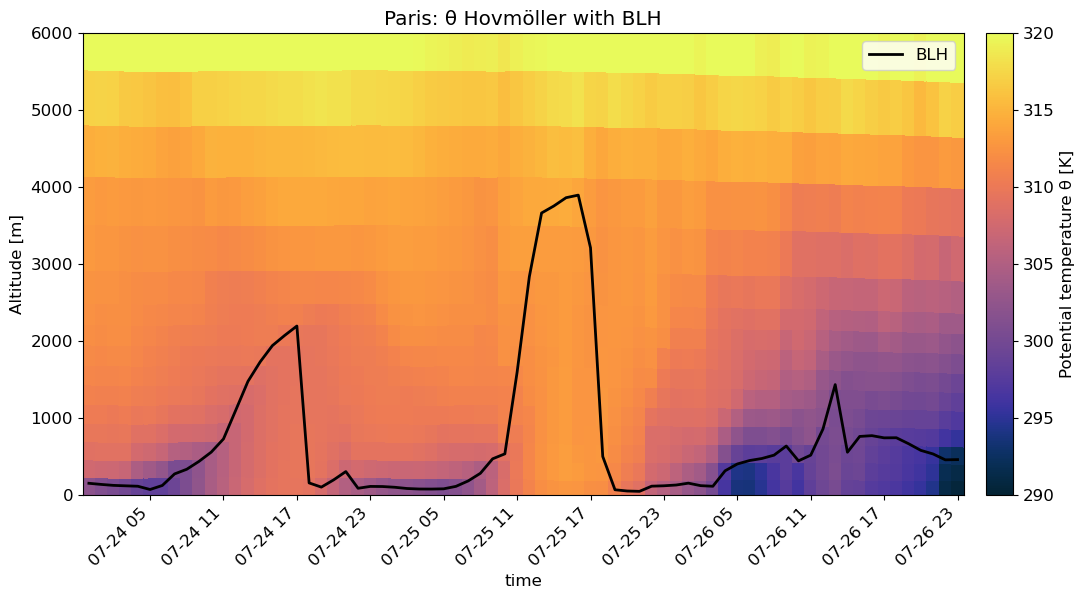

In [12]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean

plt.rcParams.update({"font.size": 12})

# -----------------------------
# Paths + time windows
# -----------------------------
final_path = "/work/uc1275/u301827/02_MSE/paris/vertical_2019/"

# file window (must match your saved filenames)
start_date = "2019-07-20"
end_date   = "2019-07-27"

# plot window (shortened period)
plot_start = "2019-07-24 00:00"
plot_end   = "2019-07-26 23:00"

# -----------------------------
# Constants
# -----------------------------
P0_HPA = 1000.0
R_D = 287.05
C_P = 1004.0
KAPPA = R_D / C_P
G = 9.81

top = 6000  # m
vmin, vmax = 290, 320

def open_era5(var):
    f = os.path.join(
        final_path, var,
        f"{var}_{pd.to_datetime(start_date):%Y%m%d}_{pd.to_datetime(end_date):%Y%m%d}_paris_hourly.nc"
    )
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")
    return xr.open_dataset(f)

# -----------------------------
# Read data
# -----------------------------
t   = open_era5("t")["t"].squeeze(drop=True)        # (time, plev)
z   = open_era5("z")["z"].squeeze(drop=True)        # (time, plev)
blh = open_era5("blh")["blh"].squeeze(drop=True)    # (time)

# ensure datetime + align
t   = t.assign_coords(time=pd.to_datetime(t.time.values))
z   = z.assign_coords(time=pd.to_datetime(z.time.values))
blh = blh.assign_coords(time=pd.to_datetime(blh.time.values))
t, z, blh = xr.align(t, z, blh, join="inner")

plev = "plev"

# Pa -> hPa if needed
p = t[plev]
p_hpa = xr.where(p.max() > 2000, p / 100.0, p)

# -----------------------------
# Derived fields
# -----------------------------
theta = t * (P0_HPA / p_hpa) ** KAPPA
theta.name = "theta"
theta.attrs["units"] = "K"

height = (z / G).rename("z")  # meters, (time, plev)

# sort levels by mean height (consistent vertical order)
theta  = theta.sortby(height.mean("time"))
height = height.sortby(height.mean("time"))

# attach 2D height coord for plotting
theta = theta.assign_coords(z=height)

# -----------------------------
# Shorten time period for plotting
# -----------------------------
theta_p = theta.sel(time=slice(plot_start, plot_end))
blh_p   = blh.sel(time=slice(plot_start, plot_end))

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[20, 0.6], wspace=0.05)
ax  = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

pcm = theta_p.plot(
    ax=ax,
    x="time",
    y="z",
    cmap=cmocean.cm.thermal,
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False,
)

cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
cbar.set_label("Potential temperature θ [K]")

# BLH overlay
ax.plot(theta_p["time"].values, blh_p.values, color="black", linewidth=2, label="BLH")

ax.set_ylabel("Altitude [m]")
ax.set_ylim(0, top)
ax.set_title("Paris: θ Hovmöller with BLH")

# nice ticks for a short (hourly) window
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
ax.tick_params(axis="x", rotation=45)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean

plt.rcParams.update({"font.size": 12})

final_path = "/work/uc1275/u301827/02_MSE/paris/vertical_2019/"
start_date = "2019-07-20"
end_date   = "2019-07-27"

# constants
P0_HPA = 1000.0
R_D = 287.05
C_P = 1004.0
KAPPA = R_D / C_P
G = 9.81
top = 6000  # m

def open_era5(var):
    f = os.path.join(
        final_path, var,
        f"{var}_{pd.to_datetime(start_date):%Y%m%d}_{pd.to_datetime(end_date):%Y%m%d}_paris_hourly.nc"
    )
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")
    return xr.open_dataset(f)

# ---- read ----
t   = open_era5("t")["t"].squeeze(drop=True)      # (time, plev)
z   = open_era5("z")["z"].squeeze(drop=True)      # (time, plev)
w   = open_era5("w")["w"].squeeze(drop=True)      # (time, plev) Pa/s (subsidence +)
v   = open_era5("v")["v"].squeeze(drop=True)      # (time, plev) m/s (northward +)
blh = open_era5("blh")["blh"].squeeze(drop=True)  # (time)

# ensure datetime + align
t   = t.assign_coords(time=pd.to_datetime(t.time.values))
z   = z.assign_coords(time=pd.to_datetime(z.time.values))
w   = w.assign_coords(time=pd.to_datetime(w.time.values))
v   = v.assign_coords(time=pd.to_datetime(v.time.values))
blh = blh.assign_coords(time=pd.to_datetime(blh.time.values))
t, z, w, v, blh = xr.align(t, z, w, v, blh, join="inner")

plev = "plev"

# Pa -> hPa if needed
p = t[plev]
p_hpa = xr.where(p.max() > 2000, p / 100.0, p)

# derived fields
theta = t * (P0_HPA / p_hpa) ** KAPPA
theta.name = "theta"

height = (z / G).rename("z")  # meters, (time, plev)

# sort by mean height (consistent vertical order)
sort_key = height.mean("time")
theta  = theta.sortby(sort_key)
height = height.sortby(sort_key)
w      = w.sortby(sort_key)
v      = v.sortby(sort_key)

# attach 2D height coordinate for plotting
theta = theta.assign_coords(z=height)
w     = w.assign_coords(z=height)
v     = v.assign_coords(z=height)

# ---- figure: 3 panels + 3 colorbars ----
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[20, 0.6],
    height_ratios=[1, 1, 1],
    wspace=0.05, hspace=0.25
)

ax1  = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])

ax2  = fig.add_subplot(gs[1, 0], sharex=ax1, sharey=ax1)
cax2 = fig.add_subplot(gs[1, 1])

ax3  = fig.add_subplot(gs[2, 0], sharex=ax1, sharey=ax1)
cax3 = fig.add_subplot(gs[2, 1])

# Panel 1: theta
pcm1 = theta.plot(
    ax=ax1, x="time", y="z",
    cmap=cmocean.cm.thermal,
    vmin=290, vmax=320,
    add_colorbar=False
)
cb1 = fig.colorbar(pcm1, cax=cax1, orientation="vertical")
cb1.set_label("Potential temperature θ [K]")
ax1.plot(theta["time"].values, blh.values, color="black", linewidth=2, label="BLH")
ax1.legend(loc="upper right")
ax1.set_title("Potential temperature")

# Panel 2: subsidence velocity (w, Pa/s)
# Note: ERA5 w is pressure vertical velocity; positive = subsidence, negative = ascent
pcm2 = w.plot(
    ax=ax2, x="time", y="z",
    cmap=cmocean.cm.balance,
    add_colorbar=False
)
cb2 = fig.colorbar(pcm2, cax=cax2, orientation="vertical")
cb2.set_label("Vertical velocity w [Pa s$^{-1}$]")
ax2.plot(w["time"].values, blh.values, color="black", linewidth=2)
ax2.set_title("Subsidence / vertical velocity")

# Panel 3: northward wind (v, m/s)
pcm3 = v.plot(
    ax=ax3, x="time", y="z",
    cmap=cmocean.cm.balance,
    add_colorbar=False
)
cb3 = fig.colorbar(pcm3, cax=cax3, orientation="vertical")
cb3.set_label("Northward wind v [m s$^{-1}$]")
ax3.plot(v["time"].values, blh.values, color="black", linewidth=2)
ax3.set_title("Northward wind")

# common formatting
for ax in (ax1, ax2, ax3):
    ax.set_ylabel("Altitude [m]")
    ax.set_ylim(0, top)
    ax.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)

ax3.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax3.tick_params(axis="x", rotation=45)
ax3.set_xlabel("Time")

plt.tight_layout()
plt.show()


In [1]:
import xarray as xr
xr.open_dataset("/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_compiled_clean_plusDerived.nc")

<xarray.Dataset>
Dimensions:          (bnds: 2, lat: 89, lon: 1280, nhyi: 138, nhym: 137, time: 7820)
Coordinates:
  * time             (time) datetime64[ns] 1940-06-01 1940-06-02 ... 2024-08-31
  * lon              (lon) float64 0.0 0.2812 0.5625 ... 359.2 359.4 359.7
  * lat              (lat) float64 64.78 64.5 64.22 63.93 ... 40.61 40.33 40.05
    plev             float64 ...
Dimensions without coordinates: bnds, nhyi, nhym
Data variables: (12/22)
    hyai             (nhyi) float64 ...
    hybi             (nhyi) float64 ...
    hyam             (nhym) float64 ...
    hybm             (nhym) float64 ...
    depth_bnds       (bnds) float64 ...
    tasmax           (time, lat, lon) float32 ...
    ...               ...
    2d_at_tasmax     (time, lat, lon) float32 ...
    blh              (time, lat, lon) float32 ...
    blh_at_tasmax    (time, lat, lon) float32 ...
    swvl1            (time, lat, lon) float32 ...
    swvl1_at_tasmax  (time, lat, lon) float32 ...
    zs               (lat, lon) float32 ...